# ReAct Agent Architecture

## Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

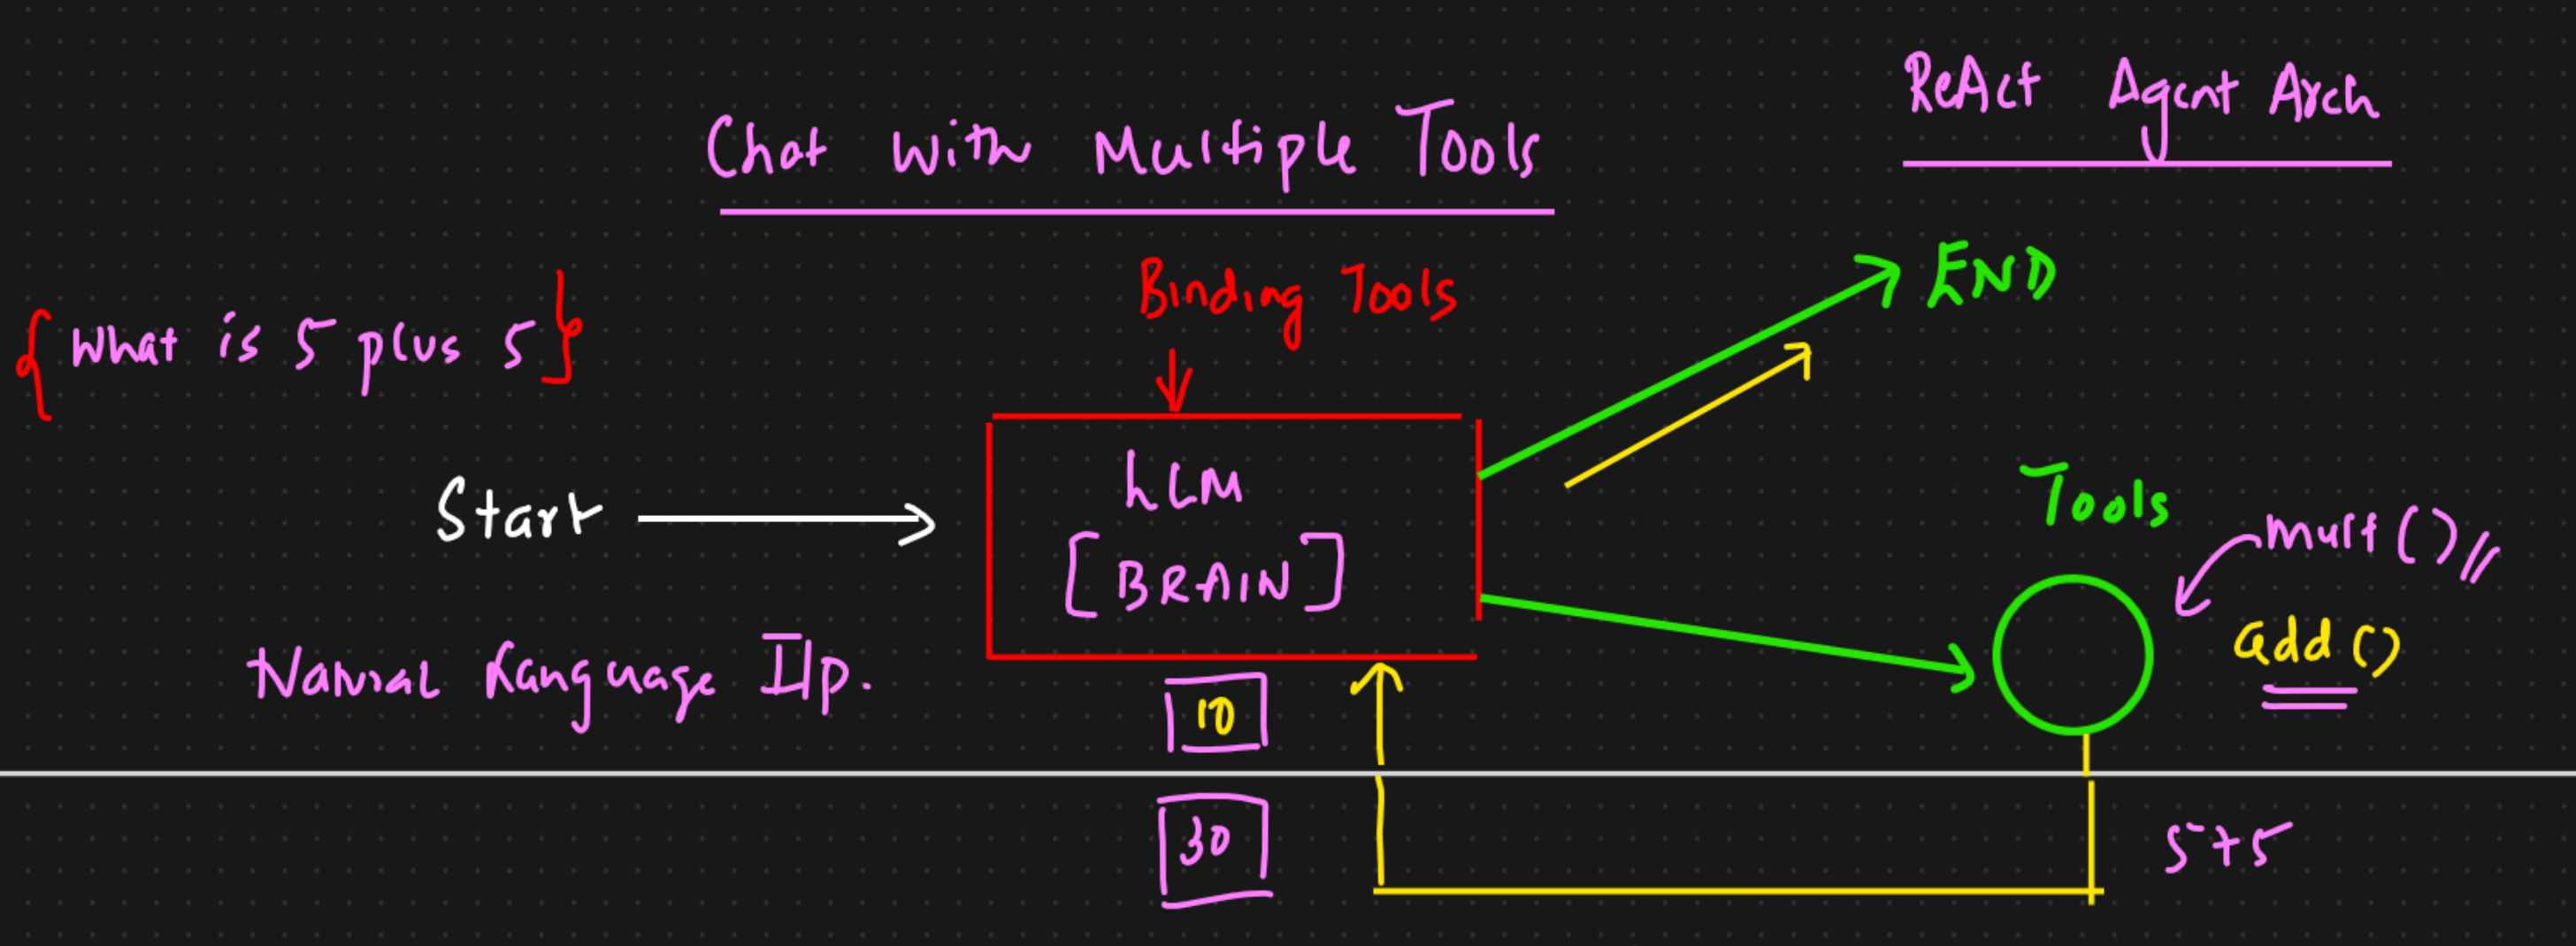

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.name

'arxiv'

In [3]:
api_wrapper_arxiv = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_arxiv)
wiki.name

'wikipedia'

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct_agent"


In [5]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b


In [6]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(
    max_results=5,
    topic="general",
)

In [7]:
tools=[arxiv,wiki,tavily,add,multiply,divide]

In [8]:
from langchain_openai import ChatOpenAI

openai_api_key = os.getenv("OPENAI_API_KEY")
openai_base_url = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="gpt-5.2-high",
    api_key=openai_api_key,
    base_url=openai_base_url
)
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002021B4627B0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002021B463380>, root_client=<openai.OpenAI object at 0x000002021B1EB230>, root_async_client=<openai.AsyncOpenAI object at 0x000002021B4630E0>, model_name='gpt-5.2-high', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://www.yxaiapp.com/v1'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv', 'description': 'A wrapper around Arxiv.org Useful for when you need to answer questions about Physics, Mathematics, Computer Science, Quantitative Biology, Quantitative Finance, Statistics, Electrical Engineering, and Economics from scientific articles on arxiv.org. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['query'

In [9]:
from langchain_core.messages import HumanMessage
llm_with_tools.invoke([HumanMessage(content="What is the recent AI news?")]).tool_calls

[{'name': 'tavily_search',
  'args': {'end_date': None,
   'exclude_domains': None,
   'include_domains': None,
   'include_images': False,
   'query': 'recent AI news major developments last week',
   'search_depth': 'advanced',
   'start_date': None,
   'time_range': 'week',
   'topic': 'news'},
  'id': 'call_Ec0cjnBT0jZ76BBI5Cnvbl19',
  'type': 'tool_call'}]

In [10]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

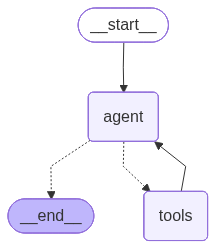

In [11]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("agent", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition
)
builder.add_edge("tools", "agent")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_EQVZWBBvOMliTgWK1egmtkRo)
 Call ID: call_EQVZWBBvOMliTgWK1egmtkRo
  Args:
    end_date: 2025-03-03
    exclude_domains: None
    include_domains: None
    include_images: False
    query: March 3 2025 AI news
    search_depth: advanced
    start_date: 2025-02-27
    time_range: None
    topic: general
  add (call_1GMQEkWH936q5jov3QTZ7HxV)
 Call ID: call_1GMQEkWH936q5jov3QTZ7HxV
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "March 3 2025 AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.globalpolicywatch.com/2025/04/march-2025-ai-developments-under-the-trump-ad

In [13]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

Machine learning (ML) is a branch of artificial intelligence where computers learn patterns from data to make predictions or decisions, instead of being explicitly programmed with fixed rules.

### How it works (high level)
1. **Data**: Examples (e.g., emails labeled “spam” or “not spam”).
2. **Model**: A mathematical function with adjustable parameters.
3. **Training**: The model adjusts its parameters to reduce errors on the examples.
4. **Inference**: After training, the model is used on new, unseen data.

### Common types of machine learning
- **Supervised learning**: Learns from labeled data (e.g., predict house prices, classify images).
- **Unsupervised learning**: Finds structure in unlabeled data (e.g., clustering customers into groups).
- **Reinforcement learning**: Learns by trial and error

# Agent Memory
## Aim
## Lets introduce Agent With Memory

In [14]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================

5 plus 8 equals **13**.


In [15]:
messages=graph.invoke({"messages":HumanMessage(content="Divide that by 5")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

What number should I divide by 5? If you tell me the value (or paste the expression), I’ll compute it.


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

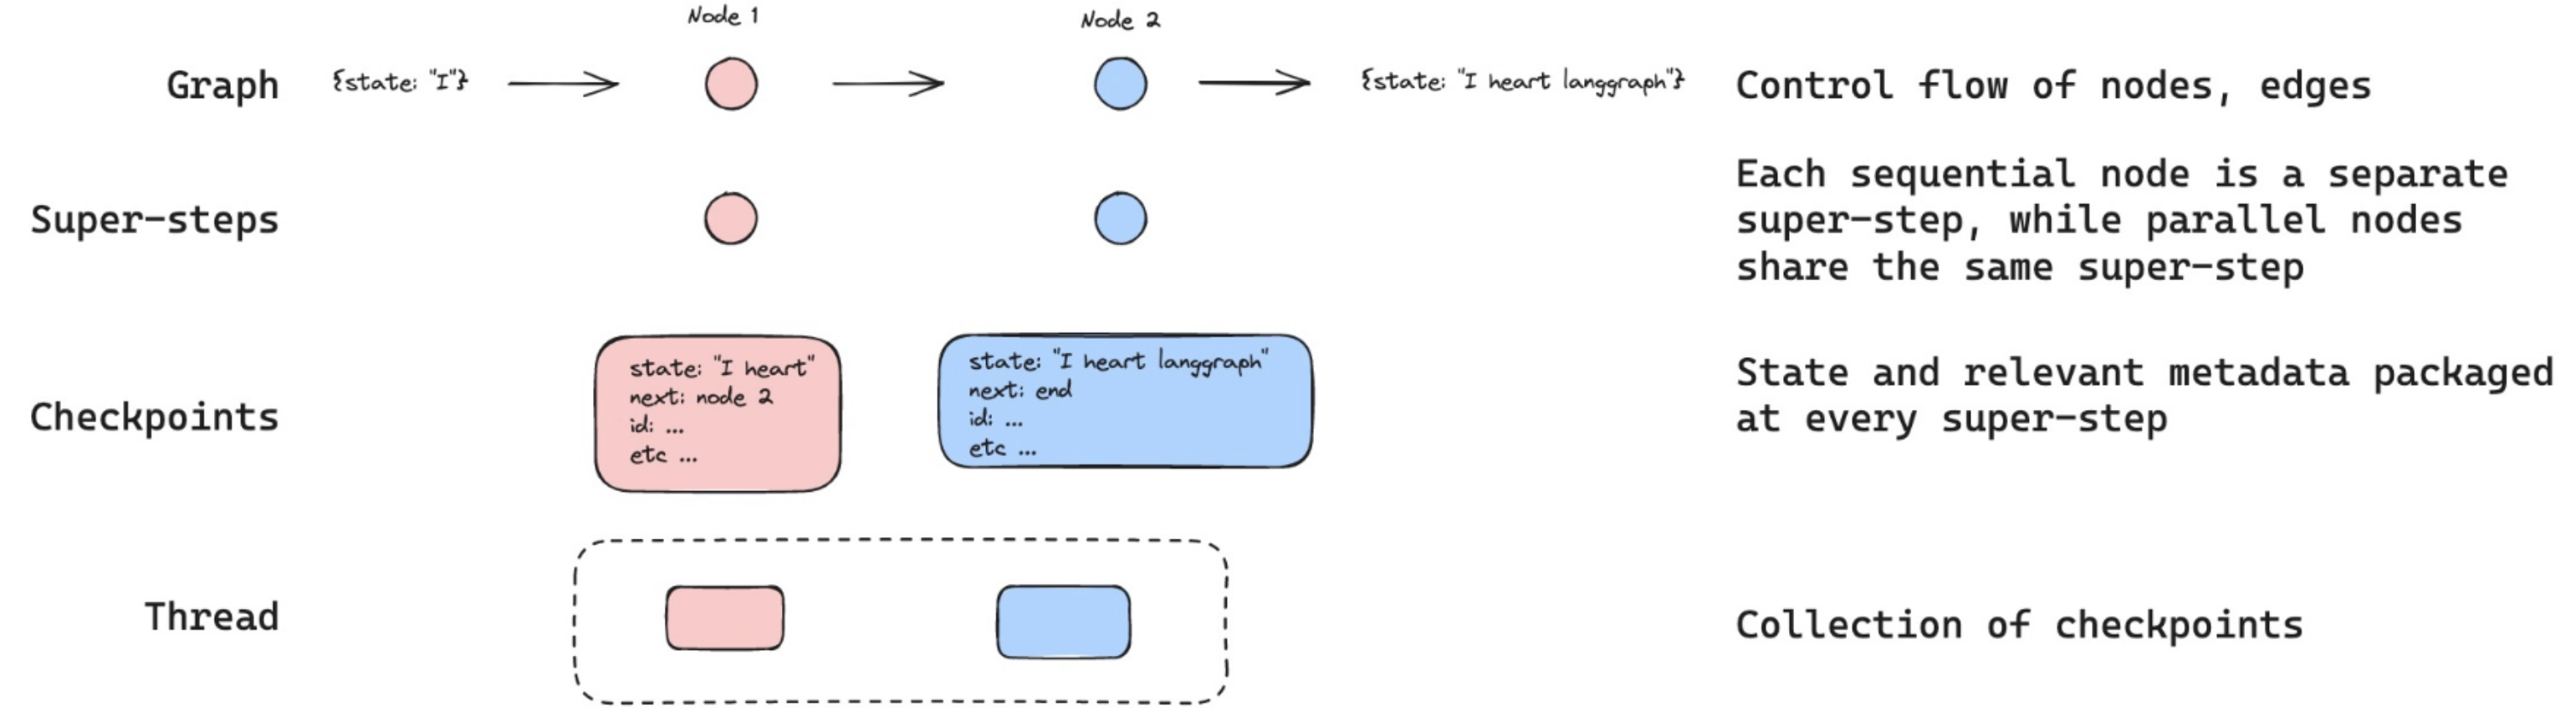

In [21]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: State):
    print(f"Processing state: {state}")
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("agent", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition
)
builder.add_edge("tools", "agent")


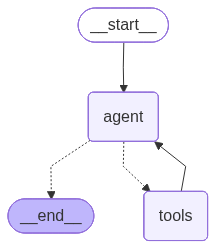

In [22]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [23]:
## Specify the thread
thread_id = "thread_1"
config = {"configurable": {"thread_id": thread_id}}

messages = [HumanMessage(content="Add 12 and 13.")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

Processing state: {'messages': [HumanMessage(content='Add 12 and 13.', additional_kwargs={}, response_metadata={}, id='3db72c7c-1ca4-4e7a-950d-8ac2aff15a85')]}
Processing state: {'messages': [HumanMessage(content='Add 12 and 13.', additional_kwargs={}, response_metadata={}, id='3db72c7c-1ca4-4e7a-950d-8ac2aff15a85'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1394, 'total_tokens': 1415, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'resp_0ad1d62761a5f92c0169baa1719aec8193b203d9bc91864114', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d0106-9a5f-7b71-9558-0824db6a3c89-0', tool_calls=[{'name': 'add', 'args': {'a': 

In [24]:
messages = [HumanMessage(content="add that number to 25")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

Processing state: {'messages': [HumanMessage(content='Add 12 and 13.', additional_kwargs={}, response_metadata={}, id='3db72c7c-1ca4-4e7a-950d-8ac2aff15a85'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1394, 'total_tokens': 1415, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'resp_0ad1d62761a5f92c0169baa1719aec8193b203d9bc91864114', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d0106-9a5f-7b71-9558-0824db6a3c89-0', tool_calls=[{'name': 'add', 'args': {'a': 12, 'b': 13}, 'id': 'call_r4zcsl1M0im5g5CBZEJsAEoU', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1394, 'output_tokens': 21, 't